# JAX features for numerical computing: an overview

This notebook is the entry point for the heat-equation, wave-equation, and N-body tutorials in this directory. It isolates the JAX ideas shared by all three so that the application notebooks can concentrate on numerical science.

JAX is best understood not as “NumPy on a GPU,” but as a system for applying program transformations to array-oriented Python functions. The important transformations here are compilation, structured control flow, vectorization, and automatic differentiation.

> JAX changes how a computation is expressed and executed. It does not select a stable discretization, validate a model, or guarantee that a GPU is faster.

## How to use this overview

**Audience.** Scientific Python users who know basic NumPy and want to understand the JAX programming model before studying larger examples. No machine-learning background is assumed.

**Prerequisites.** Required: Python functions, array shapes, indexing, and loops. Helpful but optional: derivatives and numerical time integration.

**Time.** Allow 30–40 minutes for the guided sections and 10–20 minutes for the exercises. The notebook is self-contained and should be run from top to bottom in a fresh kernel.

**Environment.** Use the `environment.yml` in this directory. Exercises and complete solutions are grouped near the end.

## Learning objectives

By the end, you should be able to:

1. explain why pure functions and immutable arrays enable JAX transformations;
2. choose `jit`, `where` or `cond`, `fori_loop`, `scan`, `vmap`, or autodiff for a stated numerical task;
3. compose transformations around the same numerical function;
4. select a CPU or GPU platform and place arrays on a chosen device;
5. distinguish compilation time, asynchronous execution, and data-transfer time;
6. anticipate recompilation, precision, memory, and scaling problems; and
7. identify which application notebook provides deeper practice for each feature.

## Feature map

| JAX idea | What problem it addresses | Heat equation | Wave equation | N-body |
|---|---|:---:|:---:|:---:|
| `jax.numpy` arrays | NumPy-like array expressions on JAX backends | ✓ | ✓ | ✓ |
| platform and device selection | choose where arrays and computation run | ✓ | ✓ | ✓ |
| immutable functional updates | transformable state without hidden mutation | ✓ | — | — |
| `jax.jit` | compile a complete numerical kernel | ✓ | ✓ | ✓ |
| static arguments and shapes | define the structure of a compiled program | step count | step count | step count and body count |
| `jnp.where` / `jax.lax.cond` | express data-dependent selection in compiled code | `where` | `where` | `where` |
| `jax.lax.fori_loop` | iterate when only a final state is required | time stepping | final wave state | final particle state |
| `jax.lax.scan` | iterate while returning a selected history | — | wave history | trajectories |
| explicit PyTree state | carry several arrays through one computation | — | two time levels | positions, velocities, acceleration |
| `jax.vmap` | map one function over an array axis | diffusivity ensemble | energy over time | diagnostics and orbit ensemble |
| `value_and_grad` | differentiate a scalar-valued function | diffusivity mismatch | wave-speed amplitude | initial-speed sensitivity |
| `block_until_ready` | make accelerator timings wait for completion | ✓ | implicit validation sync | implicit validation sync |
| scientific validation | test the algorithm, not just execution | exact solution and convergence | convergence and energy | invariants and convergence |

A dash means the notebook does not emphasize the feature, not that JAX cannot use it there.

## 1. Setup: backend and precision are part of the experiment

The application notebooks enable 64-bit arithmetic for error and conservation studies. That differs from JAX's usual accelerator-oriented 32-bit default. Precision affects accuracy, memory traffic, and hardware throughput, so select it explicitly rather than inheriting it accidentally.

In [1]:
from time import perf_counter

import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

print(f"JAX version: {jax.__version__}")
print(f"Default backend: {jax.default_backend()}")
print(f"64-bit enabled: {jax.config.jax_enable_x64}")
for device in jax.devices():
    print(f"  {device}")

JAX version: 0.10.2


Default backend: gpu
64-bit enabled: True
  cuda:0


A CPU result is valid. If an accelerator was expected but is absent, correct the environment before interpreting performance. Device discovery is a setup check, not a benchmark.

### Selecting a platform and a device

A **platform** is a kind of execution backend, such as `cpu`, `cuda`, or `tpu`; a **device** is one particular processor within that platform, such as `cpu:0` or `cuda:0`. By default, JAX initializes the available platforms, prefers an accelerator when one is available, and otherwise uses the CPU. The setup cell above reports the resulting default and its devices. For NVIDIA GPUs, configuration uses the platform name `cuda`, even though `jax.default_backend()` may report `gpu`.

For a reproducible platform choice, set `JAX_PLATFORMS` before starting Jupyter or Python:

```bash
JAX_PLATFORMS=cpu jupyter lab       # Require CPU execution.
JAX_PLATFORMS=cuda jupyter lab      # Require an NVIDIA GPU.
```

The first platform in a comma-separated list is the default, and every named platform must initialize successfully. For example, `JAX_PLATFORMS=cpu,cuda` selects the CPU by default but deliberately fails if CUDA is unavailable. Platform initialization is cached, so restart the notebook kernel after changing this setting. To restrict which NVIDIA GPUs JAX can see, set `JAX_CUDA_VISIBLE_DEVICES` as well; for example, `JAX_CUDA_VISIBLE_DEVICES=0,1` exposes only GPU 0 and GPU 1.

Within a process that has initialized both platforms, select a particular device and place work on it explicitly:

```python
cpu0 = jax.devices("cpu")[0]
cuda0 = jax.devices("cuda")[0]  # Fails clearly when CUDA is unavailable.

x_cpu = jax.device_put(np.arange(4.0), cpu0)
with jax.default_device(cuda0):
    x_gpu = jnp.arange(4.0)
```

`jax.device_put` commits an array to the selected device, and computations using that array normally follow its placement. `jax.default_device` changes the default placement within its context. Moving an existing array to another device can copy data, so placement changes belong outside the computation being timed.

Making several GPUs visible does **not** automatically split an ordinary `jit` or `vmap` computation across them. Multi-device execution requires an explicit device mesh and sharding strategy; the [multi-device wave-equation notebook](multi_device_wave_equation.ipynb) develops that more advanced model.

## 2. NumPy-like arrays, with an important difference

`jax.numpy` mirrors much of NumPy's array interface. JAX arrays are immutable: an expression cannot silently change an existing array. Use `.at[...]`, `.set(...)`, `.add(...)`, or related functional updates to create a new value.

Immutability makes data flow explicit. It does not necessarily imply a physical copy: compiled code may reuse storage when the transformation can prove that reuse is safe.

In [2]:
original = jnp.arange(5.0)
updated = original.at[2].set(-1.0)
indices = jnp.array([0, 2, 2])
accumulated = original.at[indices].add(jnp.array([10.0, 1.0, 2.0]))

print("original:   ", original)
print("updated:    ", updated)
print("accumulated:", accumulated)

E0911 15:21:42.828498 1112489 cuda_executor.cc:1182] [0] Failed to allocate device memory of 4.50GiB (4831838208 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0911 15:21:42.829631 1112489 cuda_executor.cc:1182] [0] Failed to allocate device memory of 4.05GiB (4348654080 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


original:    [0. 1. 2. 3. 4.]
updated:     [ 0.  1. -1.  3.  4.]
accumulated: [10.  1.  5.  3.  4.]


The repeated index in `.add(...)` is meaningful: both contributions to index 2 are accumulated. This is useful for assembly-like patterns, although competing updates and backend-specific implementations still deserve performance measurement.

## 3. A small numerical kernel with explicit data flow

To compare ordinary JAX execution with whole-function compilation, we first need a representative array computation. It receives changing quantities as arguments and returns its result explicitly; section 4 explains why this form gives the compiler useful scope for optimization.

A periodic second-order finite-difference approximation of the spatial Laplacian is:
$$
    (\Delta_h v)_i(t) = \frac{v_{i - 1}(t) - 2v_i(t) + v_{i + 1}(t)}{\Delta x^2}.
$$
The following pure array function is representative for a transformation-friendly function:

In [3]:
def periodic_laplacian(values, dx):
    return (
        jnp.roll(values, 1) - 2.0 * values + jnp.roll(values, -1)
    ) / dx**2


sample = jnp.sin(2.0 * jnp.pi * jnp.arange(8) / 8)
print(periodic_laplacian(sample, dx=1.0 / 8))

[-1.42108547e-14 -2.65096680e+01 -3.74903320e+01 -2.65096680e+01
 -7.10542736e-15  2.65096680e+01  3.74903320e+01  2.65096680e+01]


This pattern appears in both PDE notebooks. The N-body force has the same explicit input/output contract but operates on a larger collection of arrays. That contract is good software design in its own right; the next section shows why JAX also needs it when transforming a whole computation.

## 4. `jit`: compile at a useful boundary

JAX separates the Python program that describes work from the execution backend that performs it, such as a CPU or GPU. In this notebook, **dispatch** means Python submitting a unit of array work to that backend. Every dispatch requires some bookkeeping and scheduling, so repeatedly submitting many small operations can cost noticeable time even when each operation is cheap. Dispatch describes handing over work; it does not necessarily involve copying array data between the CPU and GPU. Section 10 discusses those data transfers separately.

Without `jit`, calling `periodic_laplacian` evaluates a sequence of JAX array operations, with work repeatedly handed from Python to the backend. `jax.jit` instead traces those operations and compiles the complete function into one backend program. This is the performance reason for presenting an explicit array function first: JAX must be able to see the computation as a transformable whole before the compiler can fuse operations, reduce intermediate storage, and replace several small dispatches with one larger dispatch.

Compile an outer numerical operation—such as a complete solve—rather than decorating every small expression reflexively. Transformation-friendly code **enables** whole-function optimization; it does not guarantee that compilation will be faster. Problem size, compilation cost, memory traffic, and hardware still determine the result.

The first `jit` call includes tracing and compilation. Later calls can reuse the executable when relevant shapes, dtypes, and static arguments match.

Dispatch and execution need not finish at the same time. Depending on the backend, Python may regain control after submitting the work but before the backend has completed it; the returned JAX array then represents a result that is still being computed. Stopping a Python timer immediately can therefore measure little more than dispatch time. Calling `.block_until_ready()` on the result makes Python wait for the computation to finish, so the elapsed time includes execution. This synchronization is important for benchmarking, but is usually unnecessary between ordinary JAX operations.

Before running the next cell, predict how the warmed unjitted execution, the first `jit` call, and the warmed `jit` execution will compare. When would the initial compilation cost be recovered?

In [4]:
compiled_laplacian = jax.jit(periodic_laplacian)
large_sample = jnp.sin(
    2.0 * jnp.pi * jnp.arange(200_000, dtype=jnp.float64) / 200_000
)
large_dx = 1.0 / large_sample.size
large_sample.block_until_ready()  # Exclude input construction from the timings.

# Warm the individual operations used by the unjitted function.
periodic_laplacian(large_sample, large_dx).block_until_ready()

start = perf_counter()
unjitted_result = periodic_laplacian(large_sample, large_dx)
unjitted_result.block_until_ready()
unjitted_time = perf_counter() - start

start = perf_counter()
compiled_laplacian(large_sample, large_dx).block_until_ready()
first_call_time = perf_counter() - start

start = perf_counter()
compiled_result = compiled_laplacian(large_sample, large_dx)
compiled_result.block_until_ready()
warmed_call_time = perf_counter() - start

print(f"warmed unjitted execution:     {unjitted_time:.4f} s")
print(f"first jit call (compile + run): {first_call_time:.4f} s")
print(f"warmed jit execution:           {warmed_call_time:.4f} s")

warmed unjitted execution:     0.0030 s
first jit call (compile + run): 0.0987 s
warmed jit execution:           0.0017 s


These three numbers answer different questions. *Unjitted* does not mean that no compilation occurs: JAX may compile and cache individual array operations, whereas `jax.jit` stages and compiles the complete function as one unit. Whole-function compilation can fuse operations and reduce dispatch and intermediate-storage overhead, but its initial cost is useful only when later execution saves enough time to repay it.

These single-run timings are illustrative, not a fair CPU-versus-GPU comparison or a rigorous benchmark. A representative benchmark must also define dtypes, transfer costs, warm-up, repetitions, and the problem sizes that matter to the application.

### Tracing, shapes, and static arguments

During tracing, JAX usually knows a dynamic argument's shape and dtype but not its runtime value. This is enough when the value participates only in array calculations: for example, `rate` and `dt` can change without recompilation as long as their shapes and dtypes remain compatible. Shapes often define storage and compiled structure, however, so a new shape or dtype can trigger recompilation.

A **static argument** is different: JAX receives its concrete Python value while tracing and specializes the compiled program to that value. Mark arguments static when their values determine program structure, such as a branch chosen by Python, an array shape, or the length of a `scan`. The keyword is `static_argnames` when identifying parameters by name, or `static_argnums` when identifying them by zero-based position:

```python
# For a function whose fourth parameter is named n_steps:
by_name = jax.jit(function, static_argnames=("n_steps",))
by_position = jax.jit(function, static_argnums=(3,))
```

These two forms mean the same thing because `n_steps` is parameter 3 when counting from zero. Names are usually easier to read and remain correct if unrelated parameters are reordered. In section 5, `n_steps` controls the loop structure and the leading dimension of the history returned by `scan`, so its value must be known during tracing. A static loop bound also lets `fori_loop` use its fixed-length lowering.

Static values become part of the compilation cache key. Calling the function with `n_steps=100` and then `n_steps=200` therefore creates two specialized executables and incurs compilation twice. This is reasonable for a small, reused set of step counts, but expensive if the value changes frequently. Static arguments must also be immutable and hashable; large data arrays should remain dynamic rather than being marked static.

`jax.make_jaxpr` shows the primitive array program produced by tracing; it is a diagnostic tool, not an API learners need to memorize.

In [5]:
traced_program = jax.make_jaxpr(periodic_laplacian)(jnp.ones(4), 0.25)
print(f"traced representation: {type(traced_program).__name__}")
print(f"primitive equations:   {len(traced_program.jaxpr.eqns)}")

traced representation: ClosedJaxpr
primitive equations:   8


## 5. Selection and structured control flow

A compiled numerical program still needs choices and iteration. JAX provides array operations and structured control-flow primitives that keep those decisions and loops inside the compiled computation rather than returning control to Python between steps. `where` is included here for comparison, although it selects array elements rather than conditionally executing one branch.

### Elementwise selection and data-dependent branches

The tracing model now explains an important restriction. An ordinary Python `if` needs its condition to be a concrete `True` or `False` immediately. During tracing, an array value is represented abstractly: its shape and dtype are known, but its runtime contents usually are not. A Python `if` whose condition depends on those contents therefore cannot become part of the compiled program.

Choose the JAX operation according to the intended computation:

- Use `jnp.where(condition, value_if_true, value_if_false)` for **elementwise selection**. Both candidate arrays are formed, and the condition selects elements from them.
- Use `jax.lax.cond(predicate, true_function, false_function, operand)` when one **scalar predicate selects a whole computation**. Both branch functions are traced, so they must return the same structure with compatible shapes and dtypes; normally only the selected branch executes at runtime.

```python
def keep_positive(values):
    return jnp.where(values > 0.0, values, 0.0)


def offset_from_total(values):
    return jax.lax.cond(
        values.sum() > 0.0,
        lambda x: x - 1.0,
        lambda x: x + 1.0,
        values,
    )
```

These forms preserve data-dependent behavior inside the compiled computation. They are not automatically faster than Python branching in isolation; their advantage is that they remain valid when the surrounding numerical kernel is transformed. A normal Python `if` remains appropriate when the decision is made outside the transformed function or depends on a deliberately static configuration value.

### Iteration with `fori_loop` and `scan`

Branches choose between computations; numerical solvers also need to repeat computations. Long Python loops are a poor fit inside a compiled numerical solve: unrolling them can make tracing and compilation expensive, while leaving repeated operations outside `jit` causes repeated dispatch. `jax.lax` supplies loop primitives that remain inside the staged computation.

We use the simple recurrence $x^{n+1}=x^n(1-r\Delta t)$ as a miniature stand-in for time stepping.

The two loop primitives use different body-function contracts. `fori_loop` calls its body as `body(step_index, carry)` and expects the updated carry in return. `scan` calls its body as `body(carry, step_input)` and expects `(updated_carry, step_output)` in return. Here there is no per-step input, so `xs=None` is used and the corresponding body argument is named `_`. An underscore similarly marks an unused loop index.

`scan` returns `(final_carry, stacked_outputs)`. In this example, the final carry duplicates the last stored state, so it is named `_final_value` and otherwise ignored. The stacked outputs contain states after each step; the initial state is added separately.

In [6]:
def decay_final(initial, rate, dt, n_steps):
    """Use fori_loop when only the final state is needed."""
    def body(_, value):  # fori_loop passes (step_index, carry).
        return value * (1.0 - rate * dt)

    return jax.lax.fori_loop(0, n_steps, body, initial)


def decay_history(initial, rate, dt, n_steps):
    """Use scan when selected output from every step is required."""
    def body(value, _):  # scan passes (carry, step_input).
        new_value = value * (1.0 - rate * dt)
        return new_value, new_value  # Updated carry and stored output.

    _final_value, later_values = jax.lax.scan(
        body, initial, xs=None, length=n_steps
    )
    return jnp.concatenate((initial[None, :], later_values), axis=0)


# The step count determines compiled loop structure; each new value recompiles.
decay_final_jit = jax.jit(decay_final, static_argnames=("n_steps",))
decay_history_jit = jax.jit(decay_history, static_argnames=("n_steps",))

initial_state = jnp.linspace(1.0, 2.0, 8)
rate = 0.7
dt = 0.01
n_steps = 100
final_state = decay_final_jit(initial_state, rate, dt, n_steps)
history = decay_history_jit(initial_state, rate, dt, n_steps)

print(f"final-state shape: {final_state.shape}")
print(f"history shape:     {history.shape}")
print(f"stored states:     {history.shape[0]}")

final-state shape: (8,)
history shape:     (101, 8)
stored states:     101


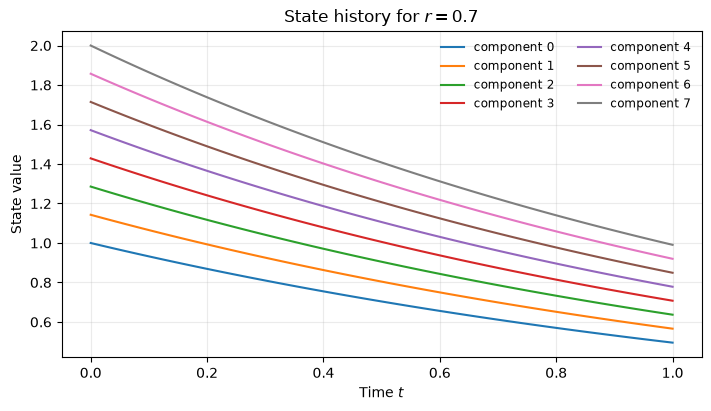

In [7]:
time_points = dt * np.arange(history.shape[0])
# Matplotlib needs host arrays; section 10 discusses this transfer.
history_on_host = np.asarray(history)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
for component, component_history in enumerate(history_on_host.T):
    ax.plot(
        time_points, component_history, label=f"component {component}"
    )
ax.set(
    xlabel="Time $t$",
    ylabel="State value",
    title=f"State history for $r = {rate}$",
)
ax.grid(alpha=0.25)
ax.legend(ncol=2, frameon=False, fontsize="small")
plt.show()

Both functions perform the same recurrence. `fori_loop` returns one state; `scan` returns 101 states and therefore consumes more memory. The plot shows what that extra storage provides: the evolution of every state component, not only its final value. Store history because a diagnostic needs it, not because it is convenient during development. For large simulations, store selected diagnostics, subsampled states, or checkpoints.

## 6. Structured state: PyTrees

The loop examples above carry one array. Real solvers often need several related arrays to advance together. JAX transformations understand nested structures of arrays called PyTrees, so tuples, lists, dictionaries, and registered data classes can carry that state without packing physically different quantities into one artificial array.

The wave solver uses `(previous_displacement, current_displacement)`. The N-body solver uses `(positions, velocities, accelerations)`. The container structure is static; the array leaves contain changing numerical values.

In [8]:
state = {
    "position": jnp.array([1.0, 2.0]),
    "velocity": jnp.array([-0.5, 0.25]),
}

def double_leaf(array):
    return 2.0 * array


doubled_state = jax.tree_util.tree_map(double_leaf, state)
print(jax.tree_util.tree_structure(state))
print(jax.tree_util.tree_structure(doubled_state))
print(doubled_state)

PyTreeDef({'position': *, 'velocity': *})
PyTreeDef({'position': *, 'velocity': *})
{'position': Array([2., 4.], dtype=float64), 'velocity': Array([-1. ,  0.5], dtype=float64)}


PyTrees organize state; they do not remove the need for clear meanings, compatible shapes, or documented units. A deeply nested state can become as difficult to understand as a monolithic array.

## 7. `vmap`: map over an array axis

`jax.vmap` transforms a function written for one input into a function that maps over an array axis. It avoids manually threading a batch dimension through every expression. This is useful for parameter ensembles and for applying diagnostics across a stored trajectory.

`vmap` exposes the mapped axis to the compiler. This often reduces Python dispatch and gives a CPU or accelerator a larger collection of work to execute efficiently. It does not, however, reduce the mathematical work: mapping over $B$ cases still requires roughly $B$ cases' worth of computation. Small batches or inexpensive functions may therefore gain little from vectorization.

Vectorization can also increase peak memory use. If a function maps a state with shape `(N,)` over `B` parameter values, the result has shape `(B, N)`, and intermediate arrays may carry that leading batch dimension as well. Compiler fusion can remove some temporaries, but it should not be assumed to eliminate the batched storage. `vmap` also does not automatically stream cases one at a time or divide them across multiple devices. When the full batch is too large, process it in chunks or distribute it explicitly. Smaller chunks reduce peak memory, while larger chunks usually expose more parallelism and require fewer launches, so the appropriate chunk size must be measured for the actual workload and hardware.

In [9]:
rates = jnp.array([0.2, 0.7, 1.5])

def solve_one_rate(one_rate):
    return decay_final(initial_state, one_rate, dt, n_steps)


solve_rate_ensemble = jax.jit(jax.vmap(solve_one_rate))
ensemble_final_states = solve_rate_ensemble(rates)
print(f"rates shape:    {rates.shape}")
print(f"results shape:  {ensemble_final_states.shape}")
print("first component for each rate:", ensemble_final_states[:, 0])

rates shape:    (3,)
results shape:  (3, 8)
first component for each rate: [0.8185668  0.49536447 0.22060891]


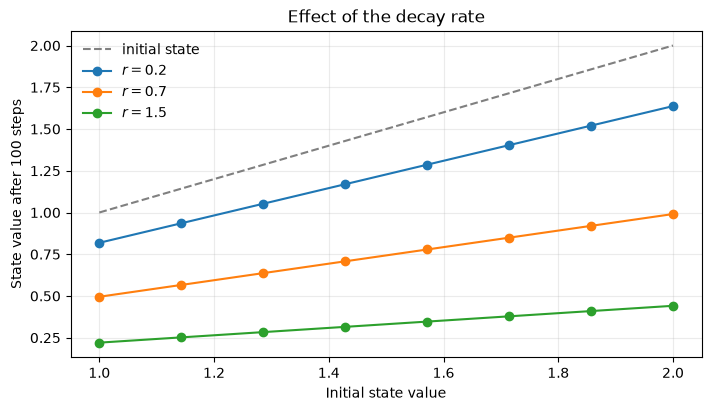

In [10]:
rates_on_host = np.asarray(rates)
initial_state_on_host = np.asarray(initial_state)
final_states_on_host = np.asarray(ensemble_final_states)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(
    initial_state_on_host,
    initial_state_on_host,
    linestyle="--",
    color="0.5",
    label="initial state",
)
for one_rate, final_values in zip(rates_on_host, final_states_on_host):
    ax.plot(
        initial_state_on_host,
        final_values,
        marker="o",
        label=f"$r = {one_rate:g}$",
    )
ax.set(
    xlabel="Initial state value",
    ylabel=f"State value after {n_steps} steps",
    title="Effect of the decay rate",
)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.show()

The leading result axis corresponds to the leading `rates` axis. The plot compares those slices against the initial state: after the same number of steps, a larger rate produces stronger decay. `vmap` changes scheduling and array structure, not the underlying numerical model.

## 8. Automatic differentiation

`jax.grad` and `jax.value_and_grad` differentiate a **scalar-valued function**: a computation that returns one number (technically, an array with shape `()`). In scientific computing, a derived quantity that summarizes or checks a simulation—such as total energy, an error norm, or a mismatch with observations—is often called a *diagnostic*. Thus, *scalar diagnostic* is informal scientific-computing shorthand, not JAX terminology. Here `final_mean_square` is scalar-valued because `jnp.mean` reduces the final array to one number.

Differentiating such quantities supports parameter sensitivities, inverse problems, design optimization, and adjoint-like calculations outside machine learning. For a vector-valued output, `jax.grad` is not the appropriate transformation; depending on the question, use a Jacobian or a Jacobian-vector/vector-Jacobian product instead.

The derivative belongs to the **implemented discrete computation**. It is not automatically the derivative of the underlying continuous model. Convergence, conditioning, non-smooth branches, iterative stopping rules, and chaotic sensitivity still matter.

In [11]:
def final_mean_square(one_rate):
    final = decay_final(initial_state, one_rate, dt, n_steps)
    return jnp.mean(final**2)


objective_value, objective_gradient = jax.value_and_grad(final_mean_square)(rate)
print(f"objective: {float(objective_value):.6f}")
print(f"d(objective)/d(rate): {float(objective_gradient):.6f}")

objective: 0.578410
d(objective)/d(rate): -1.164974


The negative derivative is physically sensible: increasing the decay rate reduces the final squared magnitude. Sign and scale checks remain valuable even when the derivative was produced automatically.

## 9. Transformations compose

The main advantage is not any transformation in isolation. Pure functions let transformations be nested. The next cell differentiates one simulation, maps that value-and-gradient calculation over several rates, and compiles the complete ensemble.

In [12]:
ensemble_value_and_gradient = jax.jit(
    jax.vmap(jax.value_and_grad(final_mean_square))
)
ensemble_objectives, ensemble_gradients = ensemble_value_and_gradient(rates)

for one_rate, value, gradient in zip(
    np.asarray(rates),
    np.asarray(ensemble_objectives),
    np.asarray(ensemble_gradients),
):
    print(
        f"rate={one_rate:.1f}: objective={value:.6f}, gradient={gradient:.6f}"
    )

rate=0.2: objective=1.579407, gradient=-3.165145
rate=0.7: objective=0.578410, gradient=-1.164974
rate=1.5: objective=0.114718, gradient=-0.232930


A useful reading order for nested transformations is inside out:

1. `value_and_grad` turns one scalar-output solve into a value-and-gradient function;
2. `vmap` maps that function over rates;
3. `jit` compiles the batched calculation.

Not every mathematically possible nesting is efficient. Measure compile time, runtime, and memory for the actual workload.

## 10. Host/device boundaries

JAX arrays may live on an accelerator. Printing a value, converting it with `np.asarray`, or extracting a Python scalar with `float(...)` requires the host to observe the result and therefore synchronizes execution.

Keep numerical kernels in JAX. Convert to NumPy at explicit boundaries for plotting, file I/O, or libraries that expect host arrays. Do not place `np.asarray` or `float` inside a function that must be transformed.

In [13]:
host_result = np.asarray(ensemble_final_states)
print("JAX result is jax.Array: ", isinstance(ensemble_final_states, jax.Array))
print("host result is ndarray:  ", isinstance(host_result, np.ndarray))
print(f"host array shape: {host_result.shape}")

JAX result is jax.Array:  True
host result is ndarray:   True
host array shape: (3, 8)


The transfer is correct and intentional here. Repeated transfers inside a time loop would force synchronization and can erase accelerator benefits.

## 11. Exercises

The overview ends here. These exercises test selection and diagnosis rather than recall of function signatures.

### Exercise 1 — choose the transformation (10 minutes)

For each task, choose the primary JAX mechanism and justify the choice. More than one transformation may eventually compose around the function.

1. Run one time integrator and retain only its final state.
2. Run the same integrator but return an energy value at every step.
3. Apply one solver independently to 50 parameter values.
4. Compute the sensitivity of a scalar final-time mismatch to one parameter.
5. Reduce Python dispatch and let the backend optimize a complete solve.

**Success criterion:** connect the required input/output contract to `fori_loop`, `scan`, `vmap`, autodiff, or `jit`, and mention one relevant cost.

<details>
<summary><strong>Solution</strong></summary>

1. Use `fori_loop`: it carries state without materializing a history. The step count may need to be static, and reverse-mode behaviour depends on the resulting loop form.
2. Use `scan`: it carries state and stacks selected per-step outputs. The cost is storage proportional to the returned history.
3. Use `vmap`: it maps the single-parameter solver over an array axis. The batch increases live memory and may need chunking.
4. Use `grad` or `value_and_grad`: the function must return a scalar and remain differentiable along the traced path. The result is a discrete sensitivity.
5. Use `jit` around the useful outer boundary. Compilation adds first-call latency, and new shapes, dtypes, or static values may compile again.

In practice, tasks 1–4 are commonly wrapped in `jit`.
</details>

### Exercise 2 — diagnose four misleading snippets (10 minutes)

Identify the problem and a defensible correction in each case:

```python
x[0] = 1.0                         # A

# B: this function is passed to jax.jit
def rescale(values):
    if values.sum() > 0.0:
        return 2.0 * values
    return 0.5 * values

%time compiled_function(x)         # C, accelerator timing
compiled_function(jnp.ones(n))     # D, for many changing values of n
```

**Success criterion:** diagnose mutation, data-dependent Python control flow, asynchronous timing, and shape-driven recompilation without blaming the GPU or compiler generically.

<details>
<summary><strong>Solution</strong></summary>

- **A:** JAX arrays are immutable. Use `x.at[0].set(1.0)` and keep the returned array.
- **B:** `values.sum() > 0.0` is one scalar, data-dependent predicate, so use `jax.lax.cond(values.sum() > 0.0, lambda x: 2.0 * x, lambda x: 0.5 * x, values)`. `jnp.where` would instead describe elementwise selection. Making the predicate static would compile a separate specialization for each value and is inappropriate for ordinary array data.
- **C:** the measurement may stop after asynchronous dispatch. Warm the compiled function and time `compiled_function(x).block_until_ready()`. Decide separately whether compilation belongs in the measured workflow.
- **D:** changing array shapes commonly triggers compilation for each new shape. Reuse a small set of shapes, pad and mask when scientifically acceptable, or accept and account for compilation. Padding wastes computation and memory, so it is not automatically better.
</details>

In [14]:
def rescale(values):
    return jax.lax.cond(
        values.sum() > 0.0,
        lambda x: 2.0 * x,
        lambda x: 0.5 * x,
        values,
    )


exercise_input = jnp.array([-2.0, 0.0, 3.0])
exercise_updated = exercise_input.at[0].set(1.0)
exercise_output = jax.jit(rescale)(exercise_updated)
print("functional update:", exercise_updated)
print("staged branch:", exercise_output)

functional update: [1. 0. 3.]
staged branch: [2. 0. 6.]


## 12. What JAX does not decide

The application notebooks deliberately keep these responsibilities visible:

- **Heat equation:** an explicit method still needs its diffusion stability limit and a convergence study.
- **Wave equation:** a stable scheme can still have numerical dispersion; the initialization and discrete energy matter.
- **N-body simulation:** integrator choice changes long-time energy behaviour, and direct all-pairs broadcasting remains $O(N^2)$ in work and memory.

Across all three, GPU execution can lose to CPU execution on small problems. Compilation cannot improve an unsuitable algorithm's asymptotic complexity, and automatic differentiation cannot certify that a sensitivity answers the scientific question intended.

## 13. Suggested learning path

1. **[Heat equation](heat_equation.ipynb):** start here for immutable arrays, `jit`, honest timing, `fori_loop`, a parameter ensemble, and a first differentiated solver.
2. **[Wave equation](wave_equation.ipynb):** continue with multi-array state, `scan`, conserved energy, numerical dispersion, and travelling waves.
3. **[N-body simulation](n_body.ipynb):** apply the same ideas to pairwise broadcasting, symplectic integration, PyTree state, multiple system sizes, batched initial conditions, and physical symmetries.

The order is pedagogical rather than mandatory. A reader interested mainly in particle methods can move directly to N-body after completing this overview.

## 14. Reproducibility checks

These small checks verify that the overview's examples agree with one another. They do not benchmark hardware or validate any of the larger scientific models.

In [15]:
np.testing.assert_allclose(np.asarray(original), np.arange(5.0))
np.testing.assert_allclose(
    np.asarray(history[-1]), np.asarray(final_state), rtol=1.0e-13
)
assert history.shape == (n_steps + 1, initial_state.size)
assert ensemble_final_states.shape == (rates.size, initial_state.size)
assert jnp.all(jnp.isfinite(ensemble_gradients))
assert objective_gradient < 0.0
np.testing.assert_allclose(
    np.asarray(exercise_output), np.array([2.0, 0.0, 6.0])
)
print("All JAX feature-overview checks passed.")

All JAX feature-overview checks passed.


## References

- [JAX: How to think in JAX](https://docs.jax.dev/en/latest/notebooks/thinking_in_jax.html)
- [JAX: Just-in-time compilation](https://docs.jax.dev/en/latest/201/jit.html)
- [JAX: Control-flow operators](https://docs.jax.dev/en/latest/control-flow.html)
- [JAX: Automatic vectorization](https://docs.jax.dev/en/latest/automatic-vectorization.html)
- [JAX: The Autodiff Cookbook](https://docs.jax.dev/en/latest/notebooks/autodiff_cookbook.html)
- [JAX: Benchmarking](https://docs.jax.dev/en/latest/benchmarking.html)
- [JAX: Default dtypes and the X64 flag](https://docs.jax.dev/en/latest/default_dtypes.html)
- [JAX: Configuration options](https://docs.jax.dev/en/latest/config_options.html)
- [JAX: Data placement](https://docs.jax.dev/en/latest/201/placement.html)
- [JAX: Distributed arrays and automatic parallelization](https://docs.jax.dev/en/latest/201/sharding.html)